In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [ ]:
f1=pd.read_csv('Unemployment in India.csv')
f2=pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

In [ ]:
f1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
f1.info()
f2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                  

In [ ]:
f1.isnull().sum()
#f2.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [ ]:
f1.describe()
#f2.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [ ]:
le=LabelEncoder()
f1['Area']=le.fit_transform(f1['Area'])

In [ ]:
f1=f1.dropna()

In [ ]:
f1=f1.drop_duplicates()

In [ ]:
f1.columns = f1.columns.str.strip()
f1['Date']=pd.to_datetime(f1['Date'])

/tmp/ipykernel_1713/218505607.py:2: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  f1['Date']=pd.to_datetime(f1['Date'])


In [ ]:
f1.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [ ]:
f1['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Chandigarh'],
      dtype=object)

In [ ]:
f1.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


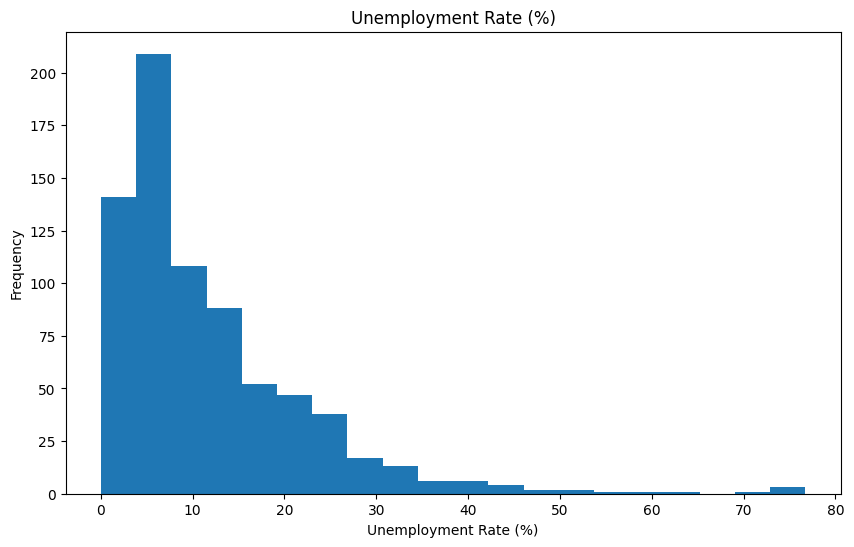

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(f1['Estimated Unemployment Rate (%)'],bins=20)
plt.title('Unemployment Rate (%)')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.show()


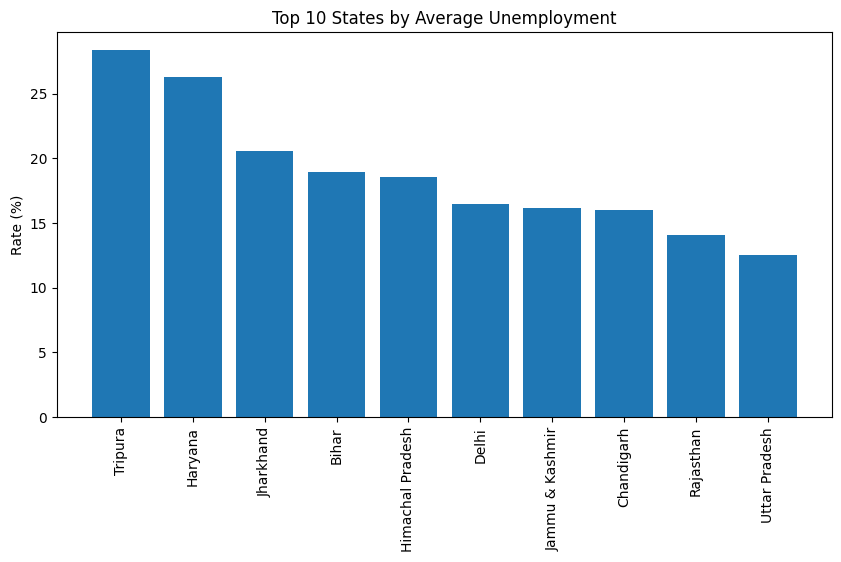

In [ ]:
top10 = f1.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top10.index, top10.values)
plt.xticks(rotation=90)
plt.title("Top 10 States by Average Unemployment")
plt.ylabel("Rate (%)")
plt.show()

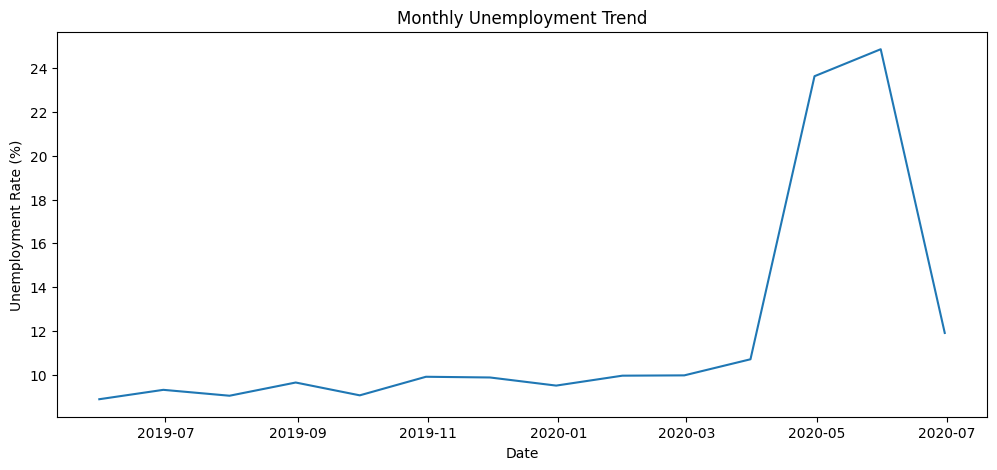

In [ ]:
monthly=f1.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values)
plt.title("Monthly Unemployment Trend")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()

In [ ]:
print(f1['Estimated Unemployment Rate (%)'].mean())
f2.columns = f2.columns.str.strip()
print(f2['Estimated Unemployment Rate (%)'].mean())

11.787945945945946
12.236928838951311


In [ ]:
before=f1[f1['Date']<'2020-03-01']
after=f1[f1['Date']>='2020-03-01']

In [ ]:
print("Before")
print(before['Estimated Unemployment Rate (%)'].mean())
print("After")
print(after['Estimated Unemployment Rate (%)'].mean())

Before
9.509533582089553
After
17.774362745098042


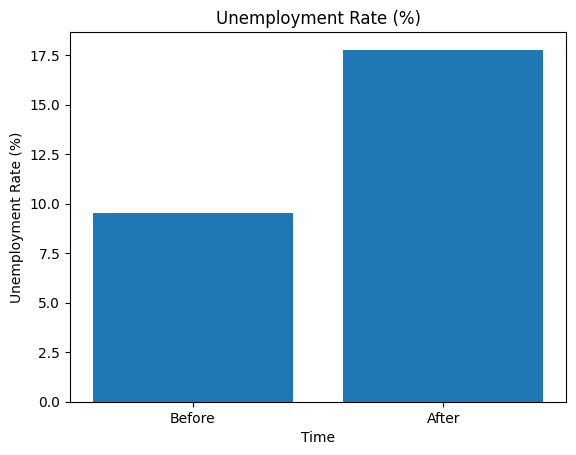

In [ ]:
labels = ['Before', 'After']
values = [before['Estimated Unemployment Rate (%)'].mean(), after['Estimated Unemployment Rate (%)'].mean()]

plt.bar(labels, values)
plt.title('Unemployment Rate (%)')
plt.xlabel('Time')
plt.ylabel('Unemployment Rate (%)')
plt.show()
